In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd()
csv_path = BASE_DIR / "weatherAUS.csv"
df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)

df.info()

outputs_dir = BASE_DIR / "outputs"
outputs_dir.mkdir(exist_ok=True)

Dataset Shape: (145460, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  C

In [2]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [3]:
df["RainTomorrow"].value_counts()
df["RainTomorrow"].value_counts(normalize=True) * 100

RainTomorrow
No     78.085384
Yes    21.914616
Name: proportion, dtype: float64

In [4]:
df.describe()
df.describe(include="object")

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,145460,145460,145460,145460,145460
unique,3436,49,16,16,16,2,2
top,2017-04-10,Canberra,W,N,SE,No,No
freq,49,3436,20241,22324,15066,113580,113583


In [5]:
df["RainTomorrow"] = df["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
print(df["RainTomorrow"].unique())

[0 1]


In [7]:
X = df.drop(
    columns=[
        "RainTomorrow",
        "Date"
    ]
)

y = df["RainTomorrow"]

print(y.unique())

[0 1]


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include="object").columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    label_encoders[col] = le

X.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,0,10.8,21.2,0.0,1.8,6.60,1,22.0,1,7,...,7.0,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,0
1,0,3.7,19.0,0.0,1.4,7.61,3,24.0,3,5,...,11.0,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,0
2,0,9.6,15.8,0.0,2.6,7.61,4,52.0,5,4,...,20.0,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,0
3,0,10.1,15.5,16.6,0.8,7.61,5,50.0,7,7,...,26.0,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,1
4,0,11.2,16.2,1.8,0.6,7.61,7,30.0,14,14,...,15.0,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,1


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (116368, 21)
X_test: (29092, 21)
y_train: (116368,)
y_test: (29092,)


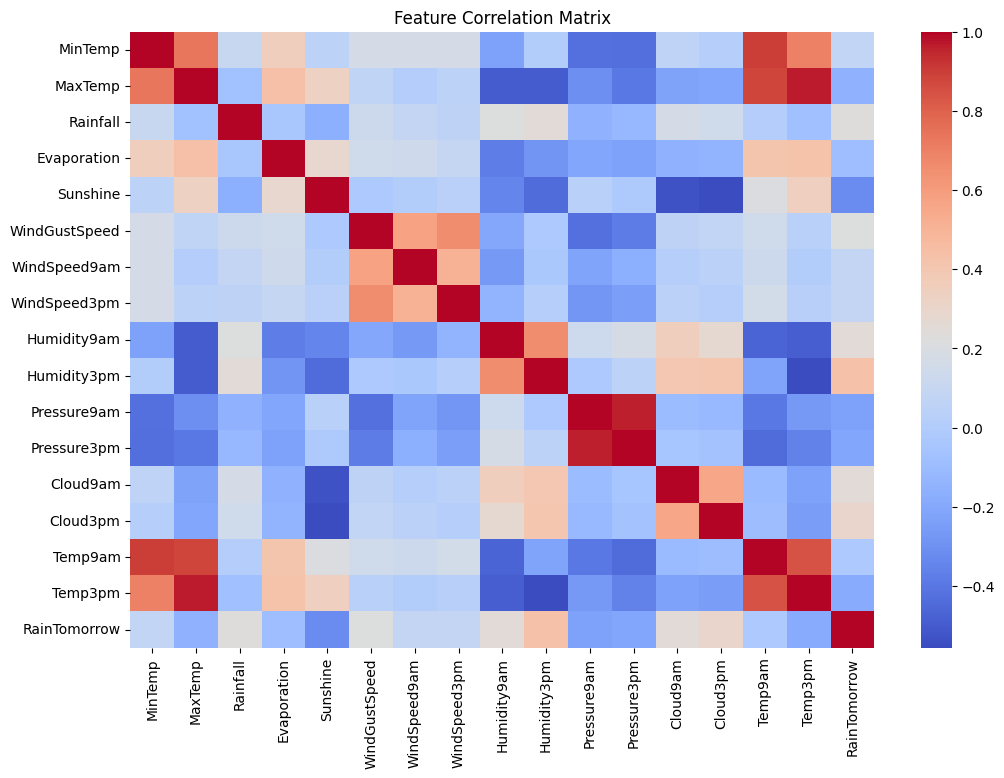

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.8562491406572253

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22717
           1       0.76      0.50      0.60      6375

    accuracy                           0.86     29092
   macro avg       0.82      0.73      0.76     29092
weighted avg       0.85      0.86      0.84     29092



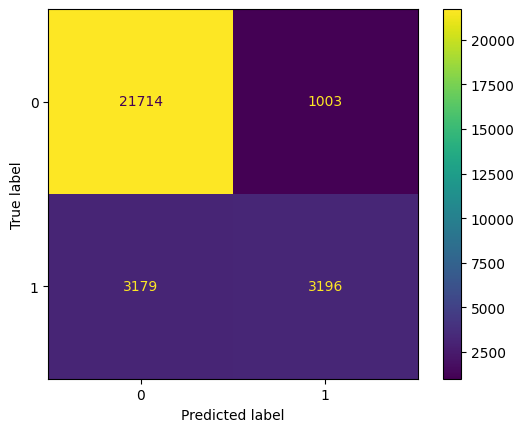

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "XGBoost":
    XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
    )

    

}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print(f"{name}: {acc:.4f}")

c:\Users\SHREYA SHARMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 0.8375
Decision Tree: 0.7851
Random Forest: 0.8562
XGBoost: 0.8585


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models["XGBoost"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

          Feature  Importance
13    Humidity3pm    0.324318
20      RainToday    0.109989
7   WindGustSpeed    0.082628
5        Sunshine    0.062648
3        Rainfall    0.056799
15    Pressure3pm    0.053833
17       Cloud3pm    0.052917
0        Location    0.026458
9      WindDir3pm    0.024627
12    Humidity9am    0.020200


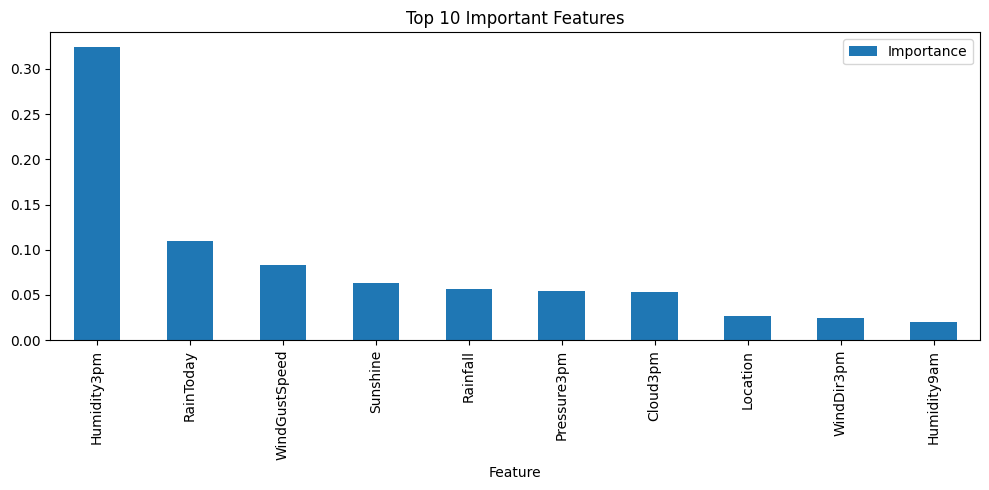

In [15]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.tight_layout()

plt.savefig(
    "outputs/feature_importance_xgboost.png"
)

plt.show()

In [16]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)



,Feature,Importance
13,Humidity3pm,0.170429
15,Pressure3pm,0.060267
7,WindGustSpeed,0.057454
14,Pressure9am,0.055476
3,Rainfall,0.055174
12,Humidity9am,0.054651
5,Sunshine,0.052080
19,Temp3pm,0.048325
2,MaxTemp,0.048176
1,MinTemp,0.047773


In [17]:
from sklearn.metrics import confusion_matrix

best_model = models["XGBoost"]

predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print(cm)

[[21579  1138]
 [ 2978  3397]]


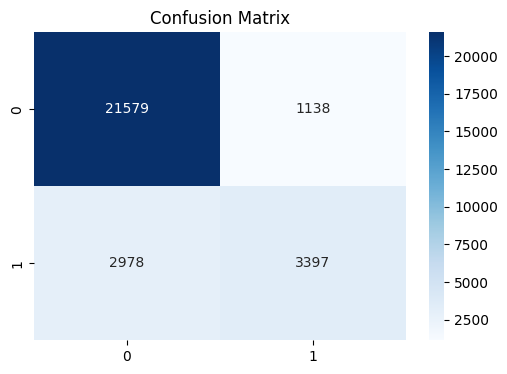

In [18]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(outputs_dir / "confusion_matrix.png")

plt.show()

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     22717
           1       0.75      0.53      0.62      6375

    accuracy                           0.86     29092
   macro avg       0.81      0.74      0.77     29092
weighted avg       0.85      0.86      0.85     29092



In [20]:
sample = X.iloc[[0]]

prediction = models["XGBoost"].predict(sample)

if prediction[0] == 1:
    print("Prediction: Rain Tomorrow")
else:
    print("Prediction: No Rain Tomorrow")

Prediction: No Rain Tomorrow


In [21]:
xgb_model = models["XGBoost"]

from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.889


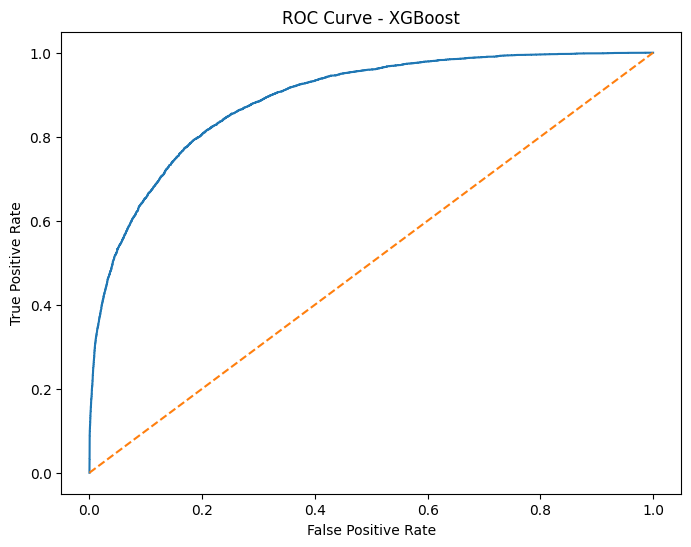

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.savefig(outputs_dir / "roc_curve_xgboost.png")

plt.show()

In [23]:
import joblib

joblib.dump(xgb_model, BASE_DIR / "weather_rain_predictor.pkl")

print("Model saved successfully!")

Model saved successfully!
